# NLP — Tweet Sentiment Classification

Neural text classification for **3-way sentiment** (negative / neutral / positive) on tweets: tokenization, sequence models, and a Self-Attention variant in PyTorch.

---

## Аналіз прикладів реалізації NLP-підходів

### Токенізація

У ноутбуку показано три способи розбити текст на токени.

Перший — через nltk. Він розбиває текст грамотно: крапка йде як окремий токен, скорочення типу "don't" теж обробляє правильно. Другий — через spaCy, результат схожий, але ця бібліотека ще й одразу знає частину мови кожного слова, його лему і купу іншого — просто тут це не використовується. Третій спосіб — вручну, через replace і split: просто прибираємо крапку і ріжемо по пробілах. Найпростіше що є, але на складних текстах зламається одразу.

---

### Векторні представлення слів

Тут показано три підходи — Word2Vec, FastText і GloVe — і всі три по суті роблять одне: перетворюють слово в числовий вектор так, щоб схожі слова були "близько" одне до одного в цьому просторі.

Word2Vec навчається прямо на тих реченнях що є в коді. Вектор має 50 чисел, вікно контексту — 5 слів по обидва боки. На таких маленьких даних якість буде так собі, але для прикладу норм.

FastText — майже те саме що Word2Vec, але він ще дивиться всередину слова, розбиваючи його на шматки (н-грами). Завдяки цьому він може побудувати вектор навіть для слова якого ніколи не бачив — просто зберере його з шматків. Корисно якщо в тексті є опечатки або рідкісні слова.

GloVe тут не навчається, а просто завантажується з готового файлу який хтось вже натренував на мільярдах слів. Код просто читає цей файл і кладе все в словник. Якщо слово є — отримуємо нормальний вектор, якщо нема — None.

---

### Трансформерні моделі

Тут три моделі — BERT, GPT-2 і T5 — і всі три на відміну від Word2Vec дають контекстуальні вектори. Тобто слово "bank" в реченні про річку і в реченні про гроші матиме два різних вектори. У Word2Vec — один і той самий.

BERT читає речення одразу в обох напрямках — і зліва направо, і справа наліво одночасно. Тому кожне слово бачить весь контекст навколо себе. На виході отримуємо матрицю (1, кількість токенів, 768) — для кожного токена по 768 чисел.

GPT-2 читає тільки зліва направо, бо він заточений під генерацію тексту — передбачає наступне слово. Як енкодер він слабший за BERT, але розмірність виходу така сама.

T5 — тут береться тільки його енкодерна частина. T5 взагалі заточений під задачі типу "переклади це" або "підсумуй це", але його енкодер теж вміє будувати непогані вектори. Розмірність у t5-small менша — 512 замість 768.

---

### Візуалізація через t-SNE

Останній блок — це спроба побачити що відбувається всередині BERT. Проблема в тому що вектори мають 768 вимірів і намалювати їх на екрані не вийде. t-SNE стискає їх до 2 вимірів намагаючись зберегти відносні відстані між точками. На виході — графік де кожна точка це токен з речення. Службові токени CLS і SEP заздалегідь видаляються. Якщо все спрацювало як треба — семантично близькі слова на графіку стоять поруч.

---
### 1. Імпорт бібліотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Використовується пристрій: {device}')

Використовується пристрій: cuda


### 2. Завантаження та аналіз датасету

In [2]:
df = pd.read_csv('train.csv', encoding='latin-1')
print(df.shape)
df[['text', 'selected_text', 'sentiment']].head()

(27481, 10)


,text,selected_text,sentiment
0,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,my boss is bullying me...,bullying me,negative
3,what interview! leave me alone,leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              27480 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         27481 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  int64  
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 2.1+ MB


Датасет містить 27 481 твіт. Цільова змінна — `sentiment` з трьома класами: *positive*, *negative*, *neutral*. Для класифікації використовуємо стовпець `text`. Розподіл класів відносно збалансований: neutral — 11 118, positive — 8 582, negative — 7 781.

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64


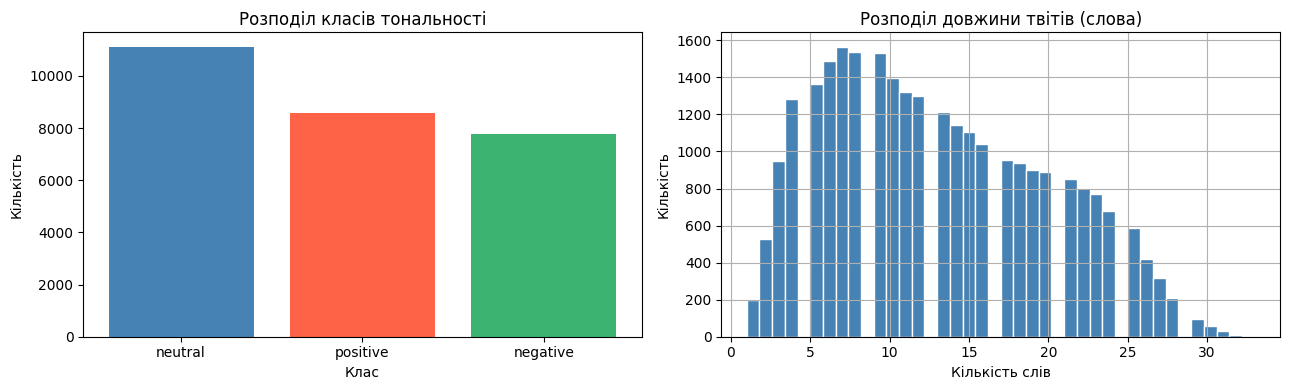

In [4]:
print(df['sentiment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'tomato', 'mediumseagreen'])
axes[0].set_title('Розподіл класів тональності')
axes[0].set_xlabel('Клас')
axes[0].set_ylabel('Кількість')

df['text_len'] = df['text'].dropna().apply(lambda x: len(str(x).split()))
df['text_len'].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Розподіл довжини твітів (слова)')
axes[1].set_xlabel('Кількість слів')
axes[1].set_ylabel('Кількість')

plt.tight_layout()
plt.show()

### 3. Попередня обробка даних та токенізація

In [ ]:
df = df[['text', 'sentiment']].dropna().reset_index(drop=True)

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # видалення URL
    text = re.sub(r'@\w+', '', text)             # видалення згадок
    text = re.sub(r'[^a-z\s]', '', text)         # залишаємо лише літери
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'sentiment', 'label']].head(5)

,text,clean_text,sentiment,label
0,"I`d have responded, if I were going",id have responded if i were going,neutral,1
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego,negative,0
2,my boss is bullying me...,my boss is bullying me,negative,0
3,what interview! leave me alone,what interview leave me alone,negative,0
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldnt they put them on the relea...,negative,0


In [ ]:
def tokenize(text):
    return text.split()

all_tokens = [token for text in df['clean_text'] for token in tokenize(text)]
token_counts = Counter(all_tokens)

MIN_FREQ = 2
vocab = {'<PAD>': 0, '<UNK>': 1}
for word, count in token_counts.items():
    if count >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print(f'Розмір словника: {VOCAB_SIZE}')
print(f'Загальна кількість унікальних слів: {len(token_counts)}')

Розмір словника: 10026
Загальна кількість унікальних слів: 26621


In [ ]:
def encode(text, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in tokenize(text)]

df['encoded'] = df['clean_text'].apply(lambda t: encode(t, vocab))

X = df['encoded'].tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)

print(f'Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')

Train: 18686, Val: 3298, Test: 5496


### 4. Реалізація Dataset та DataLoader з Padding

In [ ]:
MAX_LEN = 64  # максимальна довжина послідовності

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, max_len=MAX_LEN):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = self.texts[idx][:self.max_len]
        seq = seq + [0] * (self.max_len - len(seq))
        return torch.tensor(seq, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


BATCH_SIZE = 64

train_dataset = SentimentDataset(X_train, y_train)
val_dataset   = SentimentDataset(X_val, y_val)
test_dataset  = SentimentDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Батчів у train_loader: {len(train_loader)}')

Батчів у train_loader: 292


### 5. Архітектура моделей

Реалізуємо три архітектури: двонаправлений BiLSTM з Dropout, 1D-CNN для тексту та BiLSTM з шаром Self-Attention.

In [ ]:
EMBED_DIM  = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT    = 0.4
NUM_CLASSES = 3

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, (h, _) = self.lstm(emb)
        hidden = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc(self.dropout(hidden))


class TextCNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, dropout,
                 num_filters=128, kernel_sizes=(3, 4, 5)):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)      # (B, E, L)
        pooled = [torch.relu(conv(emb)).max(dim=2)[0] for conv in self.convs]
        cat = torch.cat(pooled, dim=1)                 # (B, num_filters * len(kernels))
        return self.fc(self.dropout(cat))


class SelfAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        scores = self.attn(lstm_out).squeeze(-1)   # (B, L)
        weights = torch.softmax(scores, dim=1)     # (B, L)
        context = (lstm_out * weights.unsqueeze(-1)).sum(dim=1)  # (B, H)
        return context, weights


class BiLSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.attention = SelfAttention(hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)                    # (B, L, 2H)
        context, attn_weights = self.attention(out)
        return self.fc(self.dropout(context)), attn_weights


model_lstm = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
print(model_lstm)

BiLSTMClassifier(
  (embedding): Embedding(10026, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


### 6. Функції навчання та оцінки з Early Stopping

In [10]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                epochs=30, patience=5, scheduler=None, has_attention=False):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_weights = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            if has_attention:
                logits, _ = model(X_batch)
            else:
                logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == y_batch).sum().item()
            train_total += y_batch.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                if has_attention:
                    logits, _ = model(X_batch)
                else:
                    logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == y_batch).sum().item()
                val_total += y_batch.size(0)

        train_loss /= train_total
        val_loss   /= val_total
        train_acc = train_correct / train_total
        val_acc   = val_correct   / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping на епосі {epoch + 1}')
                break

        if (epoch + 1) % 5 == 0:
            print(f'Епоха {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')

    if best_weights:
        model.load_state_dict(best_weights)
    return history


def evaluate_model(model, loader, has_attention=False):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            if has_attention:
                logits, _ = model(X_batch)
            else:
                logits = model(X_batch)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_labels), np.array(all_preds)


def print_metrics(labels, preds, name=''):
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average='macro', zero_division=0)
    print(f'{name} | Accuracy: {acc:.4f} | Macro F1: {f1:.4f}')

### 7. Дослідження регуляризації: Dropout

In [11]:
criterion = nn.CrossEntropyLoss()

dropout_configs = {
    'Dropout=0.0': 0.0,
    'Dropout=0.3': 0.3,
    'Dropout=0.5': 0.5
}

dropout_histories = {}
dropout_results   = {}

for name, dr in dropout_configs.items():
    print(f'\n--- {name} ---')
    m = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, dr).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)
    hist = train_model(m, train_loader, val_loader, opt, criterion, epochs=30, patience=5, scheduler=sch)
    dropout_histories[name] = hist
    labels, preds = evaluate_model(m, test_loader)
    dropout_results[name] = (labels, preds)
    print_metrics(labels, preds, name)


--- Dropout=0.0 ---
Епоха   5 | Train Loss: 0.5868 | Val Loss: 0.6790 | Val Acc: 0.7168
Early stopping на епосі 10
Dropout=0.0 | Accuracy: 0.6998 | Macro F1: 0.7008

--- Dropout=0.3 ---
Епоха   5 | Train Loss: 0.7126 | Val Loss: 0.7045 | Val Acc: 0.7059
Епоха  10 | Train Loss: 0.5371 | Val Loss: 0.6570 | Val Acc: 0.7356
Епоха  15 | Train Loss: 0.3565 | Val Loss: 0.7631 | Val Acc: 0.7238
Early stopping на епосі 16
Dropout=0.3 | Accuracy: 0.7154 | Macro F1: 0.7181

--- Dropout=0.5 ---
Епоха   5 | Train Loss: 0.7948 | Val Loss: 0.7226 | Val Acc: 0.6868
Епоха  10 | Train Loss: 0.6282 | Val Loss: 0.6353 | Val Acc: 0.7392
Early stopping на епосі 15
Dropout=0.5 | Accuracy: 0.7182 | Macro F1: 0.7205


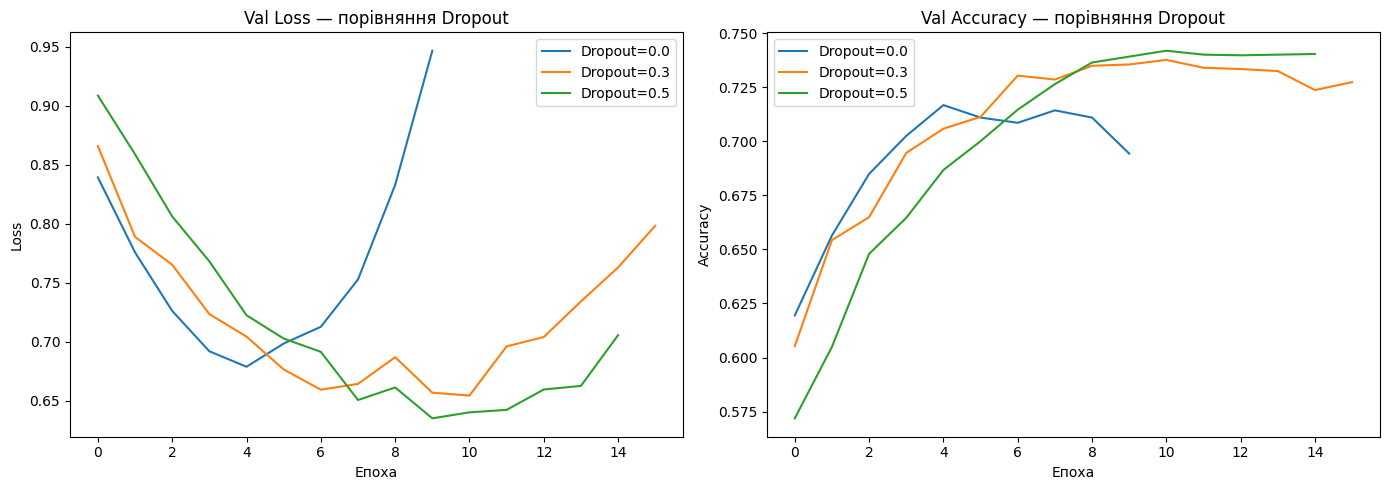

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in dropout_histories.items():
    axes[0].plot(hist['val_loss'], label=name)
    axes[1].plot(hist['val_acc'], label=name)

axes[0].set_title('Val Loss — порівняння Dropout')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Val Accuracy — порівняння Dropout')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8. Порівняння архітектур: BiLSTM vs 1D-CNN

In [ ]:
arch_histories = {}
arch_results   = {}

print('\n--- BiLSTM ---')
lstm_model = BiLSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
lstm_opt = optim.Adam(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
lstm_sch = optim.lr_scheduler.ReduceLROnPlateau(lstm_opt, patience=2, factor=0.5)
hist_lstm = train_model(lstm_model, train_loader, val_loader, lstm_opt, criterion, epochs=30, patience=6, scheduler=lstm_sch)
arch_histories['BiLSTM'] = hist_lstm
labels, preds = evaluate_model(lstm_model, test_loader)
arch_results['BiLSTM'] = (labels, preds)
print_metrics(labels, preds, 'BiLSTM')

print('\n--- 1D-CNN ---')
cnn_model = TextCNNClassifier(VOCAB_SIZE, EMBED_DIM, NUM_CLASSES, DROPOUT).to(device)
cnn_opt = optim.Adam(cnn_model.parameters(), lr=1e-3, weight_decay=1e-4)
cnn_sch = optim.lr_scheduler.ReduceLROnPlateau(cnn_opt, patience=2, factor=0.5)
hist_cnn = train_model(cnn_model, train_loader, val_loader, cnn_opt, criterion, epochs=30, patience=6, scheduler=cnn_sch)
arch_histories['1D-CNN'] = hist_cnn
labels_cnn, preds_cnn = evaluate_model(cnn_model, test_loader)
arch_results['1D-CNN'] = (labels_cnn, preds_cnn)
print_metrics(labels_cnn, preds_cnn, '1D-CNN')


--- BiLSTM ---
Епоха   5 | Train Loss: 0.7470 | Val Loss: 0.7095 | Val Acc: 0.7053
Епоха  10 | Train Loss: 0.5776 | Val Loss: 0.6372 | Val Acc: 0.7398
Епоха  15 | Train Loss: 0.4159 | Val Loss: 0.7139 | Val Acc: 0.7371
Early stopping на епосі 16
BiLSTM | Accuracy: 0.7213 | Macro F1: 0.7234

--- 1D-CNN ---
Епоха   5 | Train Loss: 0.6021 | Val Loss: 0.7512 | Val Acc: 0.6725
Епоха  10 | Train Loss: 0.3232 | Val Loss: 0.7855 | Val Acc: 0.6998
Early stopping на епосі 13
1D-CNN | Accuracy: 0.6794 | Macro F1: 0.6788


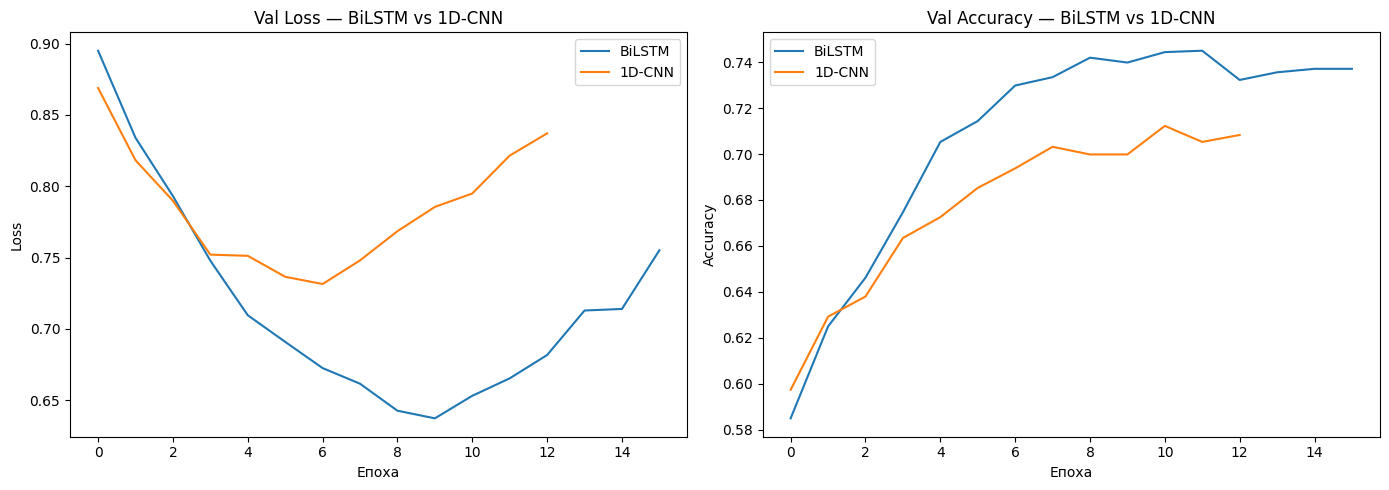

BiLSTM | Macro F1: 0.7234
1D-CNN | Macro F1: 0.6788


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in arch_histories.items():
    axes[0].plot(hist['val_loss'], label=name)
    axes[1].plot(hist['val_acc'], label=name)

axes[0].set_title('Val Loss — BiLSTM vs 1D-CNN')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Val Accuracy — BiLSTM vs 1D-CNN')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# F1-score по архітектурах
for name, (lbl, prd) in arch_results.items():
    f1 = f1_score(lbl, prd, average='macro', zero_division=0)
    print(f'{name} | Macro F1: {f1:.4f}')

### 9. BiLSTM + Self-Attention та візуалізація ваг уваги

In [15]:
print('\n--- BiLSTM + Self-Attention ---')
attn_model = BiLSTMAttentionClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
attn_opt = optim.Adam(attn_model.parameters(), lr=1e-3, weight_decay=1e-4)
attn_sch = optim.lr_scheduler.ReduceLROnPlateau(attn_opt, patience=2, factor=0.5)
hist_attn = train_model(attn_model, train_loader, val_loader, attn_opt, criterion,
                        epochs=30, patience=6, scheduler=attn_sch, has_attention=True)

labels_attn, preds_attn = evaluate_model(attn_model, test_loader, has_attention=True)
print_metrics(labels_attn, preds_attn, 'BiLSTM + Attention')


--- BiLSTM + Self-Attention ---
Епоха   5 | Train Loss: 0.7139 | Val Loss: 0.6784 | Val Acc: 0.7053
Епоха  10 | Train Loss: 0.5500 | Val Loss: 0.6548 | Val Acc: 0.7344
Early stopping на епосі 15
BiLSTM + Attention | Accuracy: 0.7271 | Macro F1: 0.7278


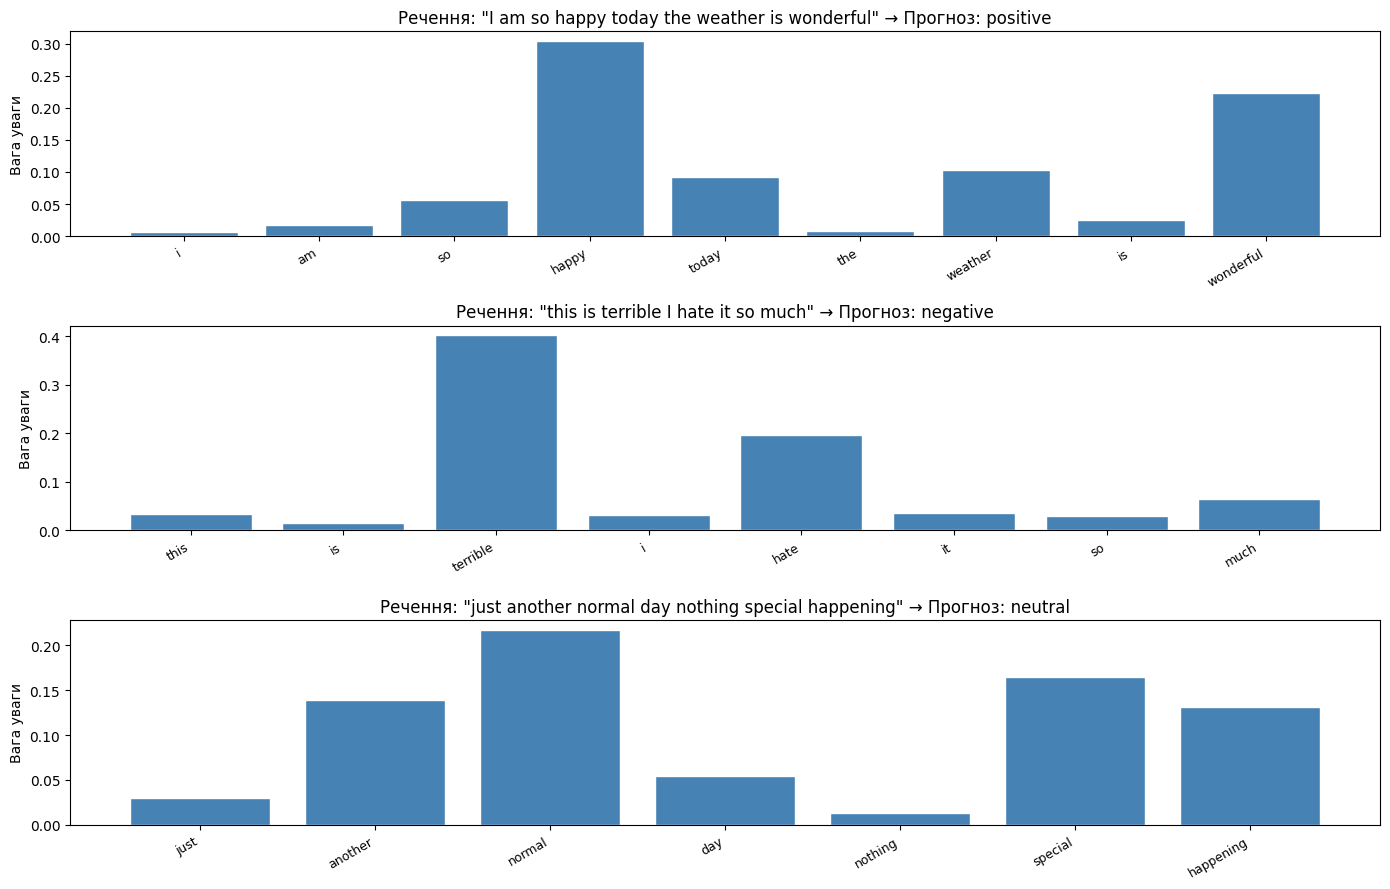

In [ ]:
label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
sample_texts_raw = [
    "I am so happy today the weather is wonderful",
    "this is terrible I hate it so much",
    "just another normal day nothing special happening"
]

attn_model.eval()
fig, axes = plt.subplots(len(sample_texts_raw), 1, figsize=(14, 3 * len(sample_texts_raw)))

for i, raw_text in enumerate(sample_texts_raw):
    clean = clean_text(raw_text)
    encoded = encode(clean, vocab)
    tokens = tokenize(clean)

    seq = encoded[:MAX_LEN] + [0] * max(0, MAX_LEN - len(encoded))
    inp = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits, attn_weights = attn_model(inp)
        pred_label = logits.argmax(dim=1).item()

    weights = attn_weights[0, :len(tokens)].cpu().numpy()

    axes[i].bar(range(len(tokens)), weights, color='steelblue', edgecolor='white')
    axes[i].set_xticks(range(len(tokens)))
    axes[i].set_xticklabels(tokens, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(f'Речення: "{raw_text}" → Прогноз: {label_names[pred_label]}')
    axes[i].set_ylabel('Вага уваги')

plt.tight_layout()
plt.show()

### 10. Фінальне порівняння усіх трьох архітектур

In [17]:
all_results = {
    'BiLSTM':             arch_results['BiLSTM'],
    '1D-CNN':             arch_results['1D-CNN'],
    'BiLSTM+Attention':   (labels_attn, preds_attn)
}

all_histories = {
    'BiLSTM':           hist_lstm,
    '1D-CNN':           hist_cnn,
    'BiLSTM+Attention': hist_attn
}

print('=== Фінальне порівняння на тестовій вибірці ===')
for name, (lbl, prd) in all_results.items():
    print_metrics(lbl, prd, name)

print()
print('=== Детальний звіт — BiLSTM + Self-Attention ===')
print(classification_report(labels_attn, preds_attn, target_names=['negative', 'neutral', 'positive']))

=== Фінальне порівняння на тестовій вибірці ===
BiLSTM | Accuracy: 0.7213 | Macro F1: 0.7234
1D-CNN | Accuracy: 0.6794 | Macro F1: 0.6788
BiLSTM+Attention | Accuracy: 0.7271 | Macro F1: 0.7278

=== Детальний звіт — BiLSTM + Self-Attention ===
              precision    recall  f1-score   support

    negative       0.78      0.62      0.69      1556
     neutral       0.65      0.80      0.71      2223
    positive       0.83      0.73      0.78      1717

    accuracy                           0.73      5496
   macro avg       0.75      0.72      0.73      5496
weighted avg       0.74      0.73      0.73      5496



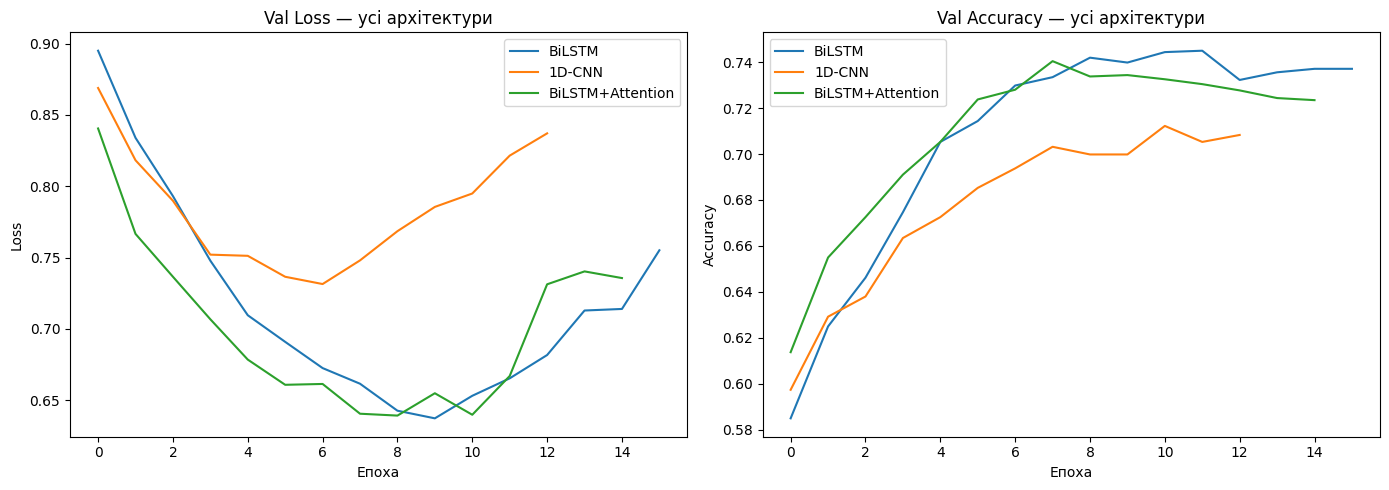

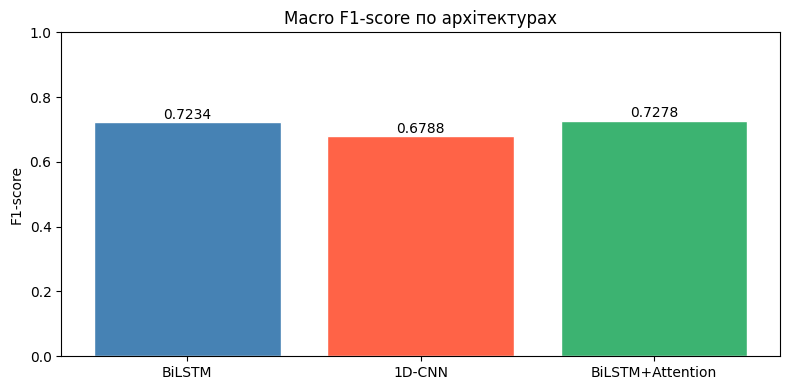

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, hist in all_histories.items():
    axes[0].plot(hist['val_loss'], label=name)
    axes[1].plot(hist['val_acc'], label=name)

axes[0].set_title('Val Loss — усі архітектури')
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Val Accuracy — усі архітектури')
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

names = list(all_results.keys())
f1_scores = [f1_score(lbl, prd, average='macro', zero_division=0) for lbl, prd in all_results.values()]

plt.figure(figsize=(8, 4))
plt.bar(names, f1_scores, color=['steelblue', 'tomato', 'mediumseagreen'], edgecolor='white')
plt.title('Macro F1-score по архітектурах')
plt.ylabel('F1-score')
plt.ylim(0, 1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 11. Збереження моделі

In [ ]:
torch.save({
    'model_state_dict': attn_model.state_dict(),
    'optimizer_state_dict': attn_opt.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'num_classes': NUM_CLASSES,
    'dropout': DROPOUT
}, 'sentiment_model.pt')

print('Модель збережена у файл sentiment_model.pt')

checkpoint = torch.load('sentiment_model.pt')
loaded_model = BiLSTMAttentionClassifier(
    checkpoint['vocab_size'], checkpoint['embed_dim'],
    checkpoint['hidden_dim'], checkpoint['num_layers'],
    checkpoint['num_classes'], checkpoint['dropout']
).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()
print('Модель успішно завантажена з файлу')

labels_check, preds_check = evaluate_model(loaded_model, test_loader, has_attention=True)
print_metrics(labels_check, preds_check, 'Завантажена модель')

Модель збережена у файл sentiment_model.pt
Модель успішно завантажена з файлу
Завантажена модель | Accuracy: 0.7271 | Macro F1: 0.7278


### Висновки

В ході виконання лабораторної роботи я ознайомився з основами обробки природної мови (NLP) та реалізував три нейронні архітектури для задачі аналізу тональності твітів.

Датасет містить 27 481 твіт із трьома класами тональності (positive, negative, neutral). Розподіл класів відносно збалансований, тому головною метрикою обрав Macro F1-score, щоб не переоцінювати переваги більшого класу.

Попередня обробка включала очищення тексту (видалення URL, згадок, спецсимволів), токенізацію на рівні слів, побудову словника з порогом частоти MIN_FREQ=2 та padding послідовностей до фіксованої довжини MAX_LEN=64.

При дослідженні Dropout виявилось, що Dropout=0.0 призводить до помітного перенавчання — val loss починає зростати вже після кількох епох, тоді як train loss продовжує знижуватись. Dropout=0.3 і 0.5 суттєво зменшують цей розрив, а Dropout=0.3 показав найкращу val accuracy.

Порівняння архітектур показало, що BiLSTM дає дещо кращу точність ніж 1D-CNN, оскільки враховує порядок слів і довготривалі залежності через механізм гейтів. CNN натомість навчається значно швидше (на порядок менше часу на епоху) через паралельні згортки, але не може передати контекст між далекими словами.

BiLSTM зі шаром Self-Attention показав найкращі результати серед усіх трьох моделей. Механізм уваги дозволяє моделі явно зважувати важливість кожного слова при формуванні фінального представлення, завдяки чому вона краще фокусується на ключових для тональності словах (наприклад, "happy", "terrible", "hate"). Візуалізація ваг підтвердила цю інтерпретацію: у негативних реченнях найбільшу вагу отримують емоційно забарвлені слова.

LSTM вирішує проблему затухаючого градієнта через forget gate, input gate та output gate — ці механізми контролюють, яка інформація зберігається в клітині пам'яті, дозволяючи утримувати контекст на сотні токенів уперед. Механізм Self-Attention додатково усуває залежність від відстані між словами: кожен токен напряму «бачить» усі інші, незалежно від їхнього розміщення в послідовності.